# D4 · Electric machines, gearboxes and the turboshaft

The series-hybrid drive train, from fuel to rotor shaft:

```
turboshaft (1,120 hp, fixed) → step-up gearbox → generator ─┐
                                                           DC bus ←── battery
 rotor ← combining gearbox ← motor lane 1 ─────────────────┤
                         ↖ motor lane 2 ──────────────────┘
```

**What you will learn**
1. The McDonald loss model: a full efficiency map from four numbers, and where the sized motor operates on it.
2. Why **torque**, not power, sizes an electric machine, and the four machine-mass models the code has been through
   (power density → torque density → a fitted database → whole units of real products).
3. Whole units with a continuous optimizer: relax, round up, re-solve.
4. Gearboxes: kinematics, losses, and smooth stage counts.
5. The fixed turboshaft: altitude and temperature lapse, the part-power fuel curve, and why the engine is not a
   design variable.

**Run time:** under a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from examples.halo_sizing import HaloRequirements, build_halo_aircraft
ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
instances = {name: inst.component for name, inst in aircraft.powertrain.topology.instances.items()}
motor, generator = instances["motor"], instances["generator"]
gearbox, generator_gearbox, turboshaft = instances["gearbox"], instances["generator_gearbox"], instances["turboshaft"]

## 1. The McDonald loss model

Electric machines are modelled after McDonald, *Modeling of Electric Motor Driven Propellers for Conceptual Aircraft
Design*, AIAA 2015-1676 (`powertrain/components/motor.py`). The loss is

$$P_L = C_0 + C_1\,\omega + C_2\,\omega^3 + C_3\,Q^2$$

- C₀: constant losses; C₁ω: friction and hysteresis; C₂ω³: windage and eddy currents, rising steeply with speed;
  C₃Q²: copper (I²R) loss, since torque ∝ current.
- The four coefficients are set from **four interpretable numbers**: the peak efficiency η̂ (0.96), the speed and
  torque where it occurs (ω̂, Q̂), and a parasite-loss split k₀ (0.5). The construction guarantees η = η̂ with zero
  slope at (ω̂, Q̂), so the map peaks where you put it.
- Motor: P_el = ωQ + P_L. Generator: P_el = ωQ − P_L. Current = P_el / V_bus.

In the sizing, ω̂ and Q̂ of the motor and of the generator are **design variables**: the optimizer places each
machine's efficiency island. Here is the sized motor lane's map with the mission's operating points on it:

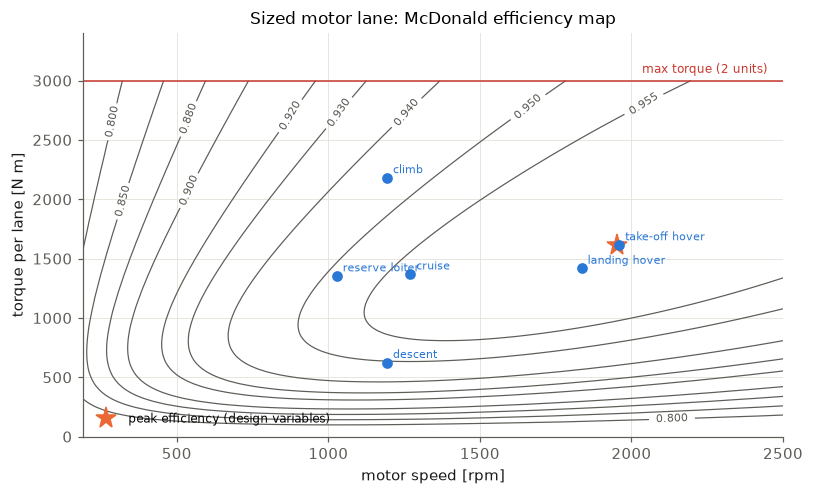

peak efficiency point: 1952 rpm, 1617 N m
PASS  efficiency at the peak point is the assumed 0.96


In [2]:
lm = motor.loss_model
speeds = np.linspace(20, motor.max_speed_rad_s, 120)
torques = np.linspace(50, motor.max_torque_Nm, 120)
W, Q = np.meshgrid(speeds, torques)
eta = W * Q / (W * Q + lm.evaluate(W, Q, 700.0))
fig, ax = plt.subplots(figsize=(7.5, 4.6))
levels = [0.80, 0.85, 0.88, 0.90, 0.92, 0.93, 0.94, 0.95, 0.955, 0.96]
cs = ax.contour(W * 30 / np.pi, Q, eta, levels=levels, colors=ink_muted, linewidths=0.8)
ax.clabel(cs, fmt="%.3f", fontsize=7)
ax.plot(lm.speed_peak_efficiency_rad_s * 30 / np.pi, lm.torque_peak_efficiency_Nm, "*", ms=14, color=orange,
        label="peak efficiency (design variables)")
for s in ref.segments:
    ax.plot(s["speed_motor_rad_s"] * 30 / np.pi, s["torque_motor_Nm"], "o", color=blue, ms=6)
    ax.annotate(s["label"], (s["speed_motor_rad_s"] * 30 / np.pi, s["torque_motor_Nm"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points", color=blue)
ax.axhline(motor.max_torque_Nm, color=red, lw=1)
ax.text(2450, motor.max_torque_Nm + 40, "max torque (2 units)", color=red, ha="right", va="bottom", fontsize=8)
ax.set_ylim(0, 3400)
ax.set(xlabel="motor speed [rpm]", ylabel="torque per lane [N m]", title="Sized motor lane: McDonald efficiency map")
ax.legend(loc="lower left", fontsize=8); plt.tight_layout(); plt.show()
print(f"peak efficiency point: {lm.speed_peak_efficiency_rad_s * 30 / np.pi:.0f} rpm, {lm.torque_peak_efficiency_Nm:.0f} N m")
check("efficiency at the peak point is the assumed 0.96",
      abs(lm.speed_peak_efficiency_rad_s * lm.torque_peak_efficiency_Nm
          / (lm.speed_peak_efficiency_rad_s * lm.torque_peak_efficiency_Nm
             + lm.evaluate(lm.speed_peak_efficiency_rad_s, lm.torque_peak_efficiency_Nm, 700.0)) - 0.96) < 1e-9)

The optimizer placed the efficiency island between the hover points (high torque) and cruise. With whole units
(section 3) the peak point only *places the map*; the limits come from the real units.

## 2. What sizes an electric machine: torque

Electromagnetic torque is the air-gap shear stress times the rotor's surface times its radius. Shear stress is
limited by magnetic and thermal loading, so at a given technology level **active mass grows with torque**. Power is
torque times speed, so a faster machine of the same mass makes more power, until losses and rotor stresses cap it.
That is the physics behind four generations of mass model in the code:

| Model | Mass | Why it was replaced |
|---|---|---|
| power / specific power (5 kW/kg motor, 4 kW/kg generator) | P_rated / p | "mass is just power divided by a constant ... can't trade direct drive against geared drive" (review, plan 018) |
| `TorqueDensityMassModel` (plan 018) | softmax(Q_max/15 N·m/kg, P_rated/10 kW/kg) | speed-independent torque density + a weak gearbox ratio penalty drove the optimizer to ~13,000 rpm motors behind 36:1 gearing |
| `DatabaseMassModel` (plan 033) | continuous torque / τ(ω_base), τ fitted to 15 real machines | still a "rubber" machine of any size |
| `UnitMachineMassModel` (plan 035, default) | **n whole units of a real product** | — |

The database fit shows torque density falls only weakly with base speed:

21 machines in data/machines/aerospace_motors.csv, 15 with continuous ratings fitted
tau(w) = 11.79 N m/kg x (w / 500 rad/s)^-0.271; rms log residual 0.375 (a factor 1.45)


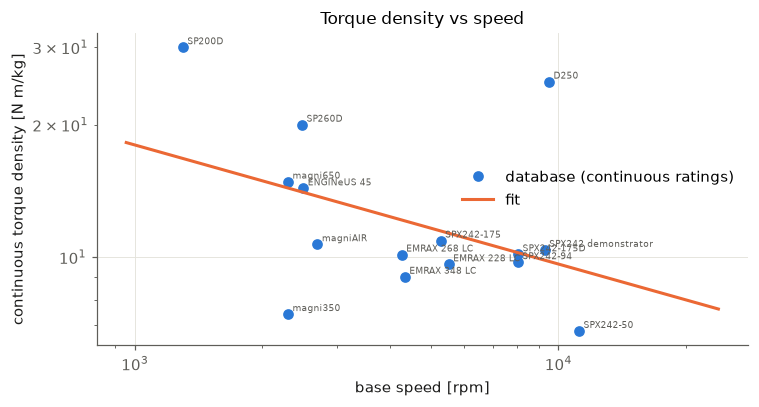

PASS  database fit exponent 0.271


In [3]:
from aircraft_closure.powertrain.machine_database import fit_torque_density, load_machine_database
records = load_machine_database()
fit = fit_torque_density(records)
print(f"{len(records)} machines in data/machines/aerospace_motors.csv, {sum(r.fit for r in records)} with continuous ratings fitted")
print(f"tau(w) = {fit.torque_density_ref_Nm_kg:.2f} N m/kg x (w / 500 rad/s)^-{fit.exponent_speed:.3f}; "
      f"rms log residual {fit.rms_log_residual:.3f} (a factor {np.exp(fit.rms_log_residual):.2f})")
fitted = [r for r in records if r.fit]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.loglog([r.speed_base_rad_s() * 30 / np.pi for r in fitted], [r.torque_density_continuous_Nm_kg() for r in fitted],
          "o", color=blue, label="database (continuous ratings)")
for r in fitted:
    ax.annotate(r.name, (r.speed_base_rad_s() * 30 / np.pi, r.torque_density_continuous_Nm_kg()), fontsize=6,
                xytext=(3, 2), textcoords="offset points", color=ink_muted)
w = np.logspace(np.log10(100), np.log10(2500), 50)
ax.loglog(w * 30 / np.pi, fit.torque_density_Nm_kg(w), color=orange, lw=2, label="fit")
ax.set(xlabel="base speed [rpm]", ylabel="continuous torque density [N m/kg]", title="Torque density vs speed")
ax.legend(); plt.tight_layout(); plt.show()
check("database fit exponent 0.271", abs(fit.exponent_speed - 0.271) < 0.001)

## 3. Whole units of real machines

The author's direction for plan 035 was "best in class, no rubber motors". So each motor lane is **n stacked units
of an Evolito D1500-class axial-flux motor** (40 kg, 1,500 N·m peak, 2,500 rpm max), and each generator **n units of
a Helix SPX242-class radial machine** (31.2 kg, 470 N·m peak, 315 kW continuous, 17,000 rpm max). The machine's
limits are n × the unit's ratings; the motor also carries an inverter allowance at 20 kW/kg (the electrical layer
is off in the baseline).

IPOPT is a continuous solver, so the sizing does it in **two explicit solves**:

1. solve with a *relaxed* count n = softmax(Q_max/Q_unit, P_rated/P_unit) (a smooth "how many units would the ratings
   need");
2. round each count **up** (`ceil(n − 1e-3)`, the tolerance absorbs softmax overshoot) and re-solve the whole problem
   with the counts fixed, warm-started from step 1.

Rounding up keeps the design feasible because capability grows with n; the second solve re-optimizes everything else
around the integer counts.

In [4]:
units = ref.machine_units
print(f"motor lane: {units['motor'][1]} units -> max torque {motor.max_torque_Nm:,.0f} N m, "
      f"continuous {motor.power_rated_W / 1e3:.0f} kW, max speed {motor.max_speed_rad_s * 30 / np.pi:,.0f} rpm, "
      f"mass {motor.get_mass():.1f} kg")
print(f"generator : {units['generator'][1]} units -> max torque {generator.max_torque_Nm:,.0f} N m, "
      f"continuous {generator.power_rated_W / 1e3:.0f} kW, max speed {generator.max_speed_rad_s * 30 / np.pi:,.0f} rpm, "
      f"mass {generator.get_mass():.1f} kg")
check("motor lane mass = 2 x 40 kg + inverter at 20 kW/kg",
      abs(motor.get_mass() - (2 * 40 + motor.power_rated_W / 20e3)) < 1e-6)
bus_out = next(f for f in ref.failure_cases if f["label"] == "bus-out hover")
print(f"\nbus-out hover: worst lane torque / max torque = {bus_out['torque_lane_to_max']:.4f}  (this sizes the motors)")

motor lane: 2 units -> max torque 3,000 N m, continuous 528 kW, max speed 2,500 rpm, mass 106.4 kg
generator : 3 units -> max torque 1,410 N m, continuous 945 kW, max speed 17,000 rpm, mass 140.8 kg
PASS  motor lane mass = 2 x 40 kg + inverter at 20 kW/kg

bus-out hover: worst lane torque / max torque = 1.0000  (this sizes the motors)


Two units per lane, four lanes in the aircraft: eight D1500-class motors. The bus-out hover, where one lane per
rotor carries the whole rotor torque, puts the lane exactly at 2 × 1,500 N·m.

## 4. Gearboxes

`Gearbox.evaluate(ω_in, Q_in)`: ω_out = ω_in / r, Q_out = r η Q_in. The loss is taken from torque so the speed
kinematics stay exact. In the sizing:

- **Rotor gearbox:** ratio r is a design variable (1.5-40); its mass is the AFDD drive-system equation (NDARC) times
  the XV-15 transmission factor; its power rating is its own design variable when the thermal model is on.
- **Generator step-up gearbox:** from the engine's 1,210 rpm output shaft up to the generator's speed.
- **Stages** (`GearStageModel`, plan 033): each stage handles up to 5:1, adds 30 % mass and 1 % loss. The stage count
  must be smooth for IPOPT, so it is either a **relaxed** count (softplus, the default) or a tanh **staircase**
  (near-integer, but with one local optimum per stage count).

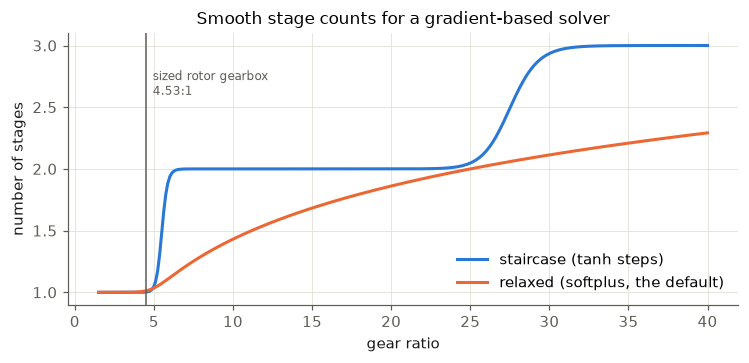

rotor gearbox 4.53:1, efficiency 0.9800, stages 1.01, mass 146 kg each
generator step-up 4.58:1 (1,210 -> 5,543 rpm), efficiency 0.9800
PASS  the sized rotor gearbox is a single stage


In [5]:
from aircraft_closure.powertrain.components.gearbox import GearStageModel
ratios = np.linspace(1.5, 40, 300)
stair, relaxed = GearStageModel(staircase=True), GearStageModel(staircase=False)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ratios, stair.count_stages(ratios), color=blue, lw=2, label="staircase (tanh steps)")
ax.plot(ratios, relaxed.count_stages(ratios), color=orange, lw=2, label="relaxed (softplus, the default)")
ax.axvline(gearbox.reduction_ratio, color=ink_muted, lw=1)
ax.text(gearbox.reduction_ratio + 0.4, 2.6, f"sized rotor gearbox\n{gearbox.reduction_ratio:.2f}:1", color=ink_muted, fontsize=8)
ax.set(xlabel="gear ratio", ylabel="number of stages", title="Smooth stage counts for a gradient-based solver")
ax.legend(); plt.tight_layout(); plt.show()
print(f"rotor gearbox {gearbox.reduction_ratio:.2f}:1, efficiency {gearbox.efficiency:.4f}, "
      f"stages {float(relaxed.count_stages(gearbox.reduction_ratio)):.2f}, mass {gearbox.get_mass():.0f} kg each")
print(f"generator step-up {1 / generator_gearbox.reduction_ratio:.2f}:1 "
      f"({assumptions.speed_output_turboshaft_rad_s * 30 / np.pi:,.0f} -> "
      f"{generator.loss_model.speed_peak_efficiency_rad_s * 30 / np.pi:,.0f} rpm), efficiency {generator_gearbox.efficiency:.4f}")
check("the sized rotor gearbox is a single stage", float(relaxed.count_stages(gearbox.reduction_ratio)) < 1.05)

With real (heavy, slow, high-torque) axial-flux units, the optimizer picks a **single 4.5:1 stage**. With rubber
machines it had picked 36:1. That swing, from one modelling decision, is one of the best illustrations in the repo of
why the machine mass model matters.

Note the generator always runs at its **peak-efficiency speed** at every flight point: the bus decouples it from the
rotor, so the flight point fixes its speed and lets only its torque vary. That pins the engine output shaft at the
engine deck's 1,210 rpm through the step-up ratio.

## 5. The turboshaft

Two **fixed, off-the-shelf 1,120 hp turboshafts** (`SimpleTurboshaft`):

- **Power available** lapses with density and temperature: P_avail = P_rated σ^n (T/T_ISA)^(−m), with n = 0.797 fitted
  to the XV-15's engine and m = 2.49 to its 95 °F curve (plans 012, 020).
- **Efficiency** at part power: η = η_full × ratio(P / P_avail), where the ratio is a **cubic** fitted to the median
  normalized sfc of a GASP_TS 1,120 hp deck over 130 Mach-altitude rows. A B-spline through the same table stalled
  IPOPT for 3,000 iterations (plan 014); the cubic is within 1.1 % above 20 % power.
- **Mass and full-power efficiency** come from AeroSandbox's turboshaft regressions; the mass is solved from the
  regression `power_turboshaft(m) / P_rated == 1` as an equality, then multiplied by the XV-15 powerplant factor
  for installation.

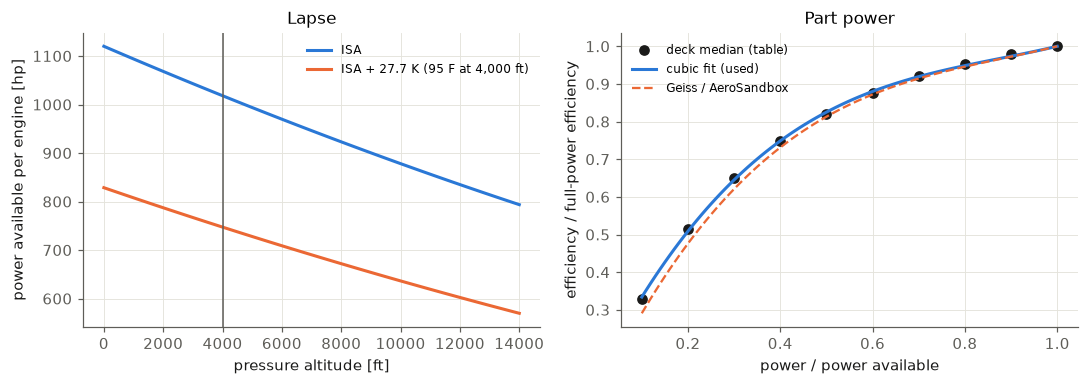

per engine: 1,120 hp at sea level, 1,018 hp at 4,000 ft, 747 hp at 4,000 ft and 95 F
installed mass 211 kg each (bare 184 kg), full-power thermal efficiency 0.266
cruise: turbines at 63% of power available, sfc 0.339 kg/kWh


In [6]:
from aircraft_closure.powertrain.components.turboshaft import (CubicPartPowerModel, GeissPartPowerModel,
                                                               deck_1120hp_part_power_model, deck_1120hp_power_fraction,
                                                               deck_1120hp_sfc_ratio)
altitudes_ft = np.linspace(0, 14000, 57)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for offset_K, color, label in ((0.0, blue, "ISA"), (27.7, orange, "ISA + 27.7 K (95 F at 4,000 ft)")):
    available = [turboshaft.power_available_W(asb.Atmosphere(altitude=h * u.foot, temperature_deviation=offset_K)) / u.hp
                 for h in altitudes_ft]
    axes[0].plot(altitudes_ft, available, color=color, lw=2, label=label)
axes[0].axvline(4000, color=ink_muted, lw=1)
axes[0].set(xlabel="pressure altitude [ft]", ylabel="power available per engine [hp]", title="Lapse")
axes[0].legend(fontsize=8)
throttle = np.linspace(0.1, 1, 91)
axes[1].plot(deck_1120hp_power_fraction, 1 / np.array(deck_1120hp_sfc_ratio), "o", color=ink, label="deck median (table)")
axes[1].plot(throttle, deck_1120hp_part_power_model().efficiency_ratio(throttle), color=blue, lw=2, label="cubic fit (used)")
axes[1].plot(throttle, GeissPartPowerModel().efficiency_ratio(throttle), color=orange, lw=1.5, ls="--", label="Geiss / AeroSandbox")
axes[1].set(xlabel="power / power available", ylabel="efficiency / full-power efficiency", title="Part power")
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()
hot = asb.Atmosphere(altitude=4000 * u.foot, temperature_deviation=27.7)
print(f"per engine: {turboshaft.power_available_W(asb.Atmosphere(altitude=0)) / u.hp:,.0f} hp at sea level, "
      f"{turboshaft.power_available_W(asb.Atmosphere(altitude=4000 * u.foot)) / u.hp:,.0f} hp at 4,000 ft, "
      f"{turboshaft.power_available_W(hot) / u.hp:,.0f} hp at 4,000 ft and 95 F")
print(f"installed mass {turboshaft.get_mass():.0f} kg each (bare {ref.design.mass_turboshaft_bare_kg:.0f} kg), "
      f"full-power thermal efficiency {ref.thermal_efficiency_turboshaft:.3f}")
cruise = next(s for s in ref.segments if s["label"] == "cruise")
sfc = cruise["fuel_kg"] / (cruise["duration_s"] / 3600) / (cruise["power_turboshafts_W"] / 1e3)
print(f"cruise: turbines at {cruise['power_turboshafts_W'] / 2 / turboshaft.power_available_W(asb.Atmosphere(altitude=cruise['altitude_start_m'])):.0%} "
      f"of power available, sfc {sfc:.3f} kg/kWh")

On a hot day at 4,000 ft each engine has two-thirds of its rated power. With fixed engines that gap is filled by the
battery, which is why hover is battery-assisted and why the hot-day hover is a separate requirement.

**Why are the engines fixed?** In plan 017 the author fixed them: "turbine power required can never exceed turbo
power available". A program buys an off-the-shelf engine; a rubber (scalable) engine lets the optimizer buy power
nobody sells. Fixing them exposed the real trade: payload against speed. With two 1,120 hp engines, payload falls to
zero near 228 kt, so the original 250 kt requirement was infeasible at any aircraft size and became 210 kt. It also
created the battery's role: assist in hover, recharge in cruise.

## Why it is built this way

- **McDonald losses:** four interpretable numbers give a realistic efficiency island without proprietary maps, it
  scales with symbolic ratings, and it is a smooth polynomial.
- **Torque sizes machines:** it is the physics, and it is what makes rotor speed, gear ratio and direct drive real
  trades. (Direct drive was checked: about 31 kN·m per motor, about 2 t of motors; infeasible.)
- **Whole units:** real products come in discrete sizes; the unit model replaced optimistic rubber scaling and
  flipped the drive architecture from fast motors with 36:1 gearing to slow axial-flux motors with one 4.5:1 stage.
- **Relax, round up, re-solve:** the honest way to get integers out of an NLP without a mixed-integer solver.
- **Cubic part power, single-exponent lapse:** smooth and cheap, fitted to data, accurate where the engine operates.

## What it can't do

- **The McDonald map is a parametric shape**, not a manufacturer map; with units, ω̂ and Q̂ place the map wherever the
  optimizer likes, not where the real product's map is. No voltage dependence (field weakening), no temperature
  dependence of losses.
- **Unit data are partly assumed:** the D1500 has no published continuous rating (the data note says its 285 kW is a
  30 s rating); the 1,400 N·m continuous figure is an assumption (35 N·m/kg). One catalogue product per role.
- **Rounding up is not an integer optimum**: a different count with a re-optimized design could be lighter; nobody
  enumerated it.
- **Relaxed gear stages** are non-integer (the sized gearbox happens to be one stage); no torque-speed envelope; no
  clutch or combiner mass for the lanes beyond the AFDD drive weight.
- **Turboshaft:** one lapse exponent, no ram recovery or Mach effect, no contingency rating, fixed output speed, no
  tailpipe thrust, no exhaust heat. The deck's own altitude columns were non-monotonic and are not used; only its
  normalized part-power curve is.

## What's next

- Supplier data sheets (efficiency maps, continuous and peak ratings, thermal limits) for the motors, generators,
  inverters and gearboxes, fed into the same component interfaces (README, propulsion work package).
- Enumerate unit catalogues and mixed unit counts (`NEXT_STEPS.md` §9), and integer stage counts by enumeration.
- The installed engine deck with its real altitude and Mach behaviour, once its correction convention is known
  (`docs/decisions/014`).

## Check yourself

<details><summary>1. Why did switching from rubber to whole-unit machines change the gear ratio from 36:1 to 4.5:1?</summary>

With a speed-independent torque density (and AFDD's weak ratio penalty), a fast, low-torque motor behind a big
reduction was the lightest option. Real axial-flux units are low-speed, high-torque products (2,500 rpm max), so the
optimizer runs them near their speed and needs only a single stage.
</details>

<details><summary>2. How do you get integer machine counts out of IPOPT?</summary>

Solve with a smooth relaxed count, round up (feasibility is monotone in the count), and re-solve the whole problem
with the counts fixed, warm-started from the relaxed solution. Two explicit solves, no loop. It is not guaranteed to
be the integer optimum.
</details>

<details><summary>3. Why is the generator speed not a per-point variable?</summary>

The DC bus decouples generator speed from rotor speed, so running the generator at its peak-efficiency speed is
near-optimal and removes a variable per point; torque carries the load. The engine output speed then follows through
the fixed step-up ratio (1,210 rpm, the deck's output speed).
</details>

<details><summary>4. Why is throttle measured against power available, not rated power?</summary>

The deck's part-power curve is normalized to the maximum power at each Mach-altitude row; the efficiency penalty
depends on how far the engine is from its maximum *at that condition*.
</details>

In [7]:
check_summary()

4 of 4 checks passed
